# Student Performance Predictor — Improved Training Notebook
### Data Cleaning + Feature Analysis + Model Training + Flask Integration


---
## CELL 0 — Install Dependencies
Run once. Skip if already installed.

In [ ]:
# Run this once to install required packages
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn joblib flask flask-cors -q
print('✅ All packages ready!')

✅ All packages ready!


---
## CELL 1 — Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

# Load dataset
df = pd.read_csv(r'D:\studyPlanPrediction\model\students_dataset.csv')

print(f'✅ Loaded {len(df)} student records with {len(df.columns)} columns')
print(f'Columns: {df.columns.tolist()}')
df.head(5)

✅ Loaded 175 student records with 22 columns
Columns: ['student_id', 'name', 'grade', 'subject', 'exam_date', 'past_mark_1', 'past_mark_2', 'past_mark_3', 'past_mark_4', 'past_mark_5', 'avg_marks', 'last_mark', 'marks_std', 'marks_trend', 'study_hours_per_day', 'study_consistency', 'attendance_pct', 'weak_topics', 'strong_topics', 'num_weak_topics', 'days_until_exam', 'future_score']


,student_id,name,grade,subject,exam_date,past_mark_1,past_mark_2,past_mark_3,past_mark_4,past_mark_5,...,marks_std,marks_trend,study_hours_per_day,study_consistency,attendance_pct,weak_topics,strong_topics,num_weak_topics,days_until_exam,future_score
0,STU_001,Ananya Sharma,11,History,2026-05-23,64.4,62.0,66.5,71.4,63.6,...,3.25,0.78,3.7,0.74,68.7,Medieval Period|Industrial Revolution,Gupta Dynasty|Mughal Empire,2,58,61.5
1,STU_002,Aarav Gupta,12,Computer Science,2026-05-08,53.7,60.2,59.0,66.2,61.3,...,4.02,2.12,3.6,0.51,84.0,Algorithms|OOP Concepts|Database Normalization,Flowcharts|HTML/CSS|Functions,3,43,56.7
2,STU_003,Amit Patel,9,History,2026-05-01,72.1,75.3,75.6,89.1,81.9,...,6.05,3.34,3.5,0.76,91.2,Industrial Revolution|Cold War,Vedic Period|British Rule|National Movement,2,36,77.8
3,STU_004,Rajat Shah,10,Computer Science,2026-05-19,78.5,75.9,74.6,73.7,68.2,...,3.40,-2.28,3.6,0.66,78.1,Sorting Algorithms,Loops|Functions|Flowcharts|Variables,1,54,57.0
4,STU_005,Archana Iyer,11,Physics,2026-05-15,92.9,94.2,87.5,91.8,96.7,...,3.04,0.52,5.0,0.89,94.7,NaN,Ohm's Law|Pressure|Simple Pendulum|Speed & Vel...,0,50,92.7


---
## CELL 2 — Data Exploration

In [ ]:
print('=== BASIC STATISTICS ===')
print(df.describe().round(2))

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0])

print('\n=== SUBJECTS ===' )
print(df['subject'].value_counts())


print('\n=== GRADE DISTRIBUTION ===')
print(df['grade'].value_counts().sort_index())

=== BASIC STATISTICS ===
        grade  past_mark_1  past_mark_2  past_mark_3  past_mark_4  \
count  175.00       175.00       175.00       175.00       175.00   
mean    10.54        67.36        67.73        67.63        69.07   
std      1.08        13.76        15.27        16.31        16.69   
min      9.00        36.20        33.50        30.60        32.30   
25%     10.00        59.25        58.50        56.90        59.20   
50%     11.00        67.60        67.60        67.30        69.80   
75%     11.00        77.25        77.10        78.70        81.10   
max     12.00        95.80        99.30       100.00       100.00   

       past_mark_5  avg_marks  last_mark  marks_std  marks_trend  \
count       175.00     175.00     175.00     175.00       175.00   
mean         68.79      68.12      68.79       4.38         0.42   
std          17.16      15.21      17.16       1.51         1.80   
min          29.80      38.72      29.80       0.42        -3.64   
25%          

---
## CELL 3 — Correlation Heatmap (shows which features matter)

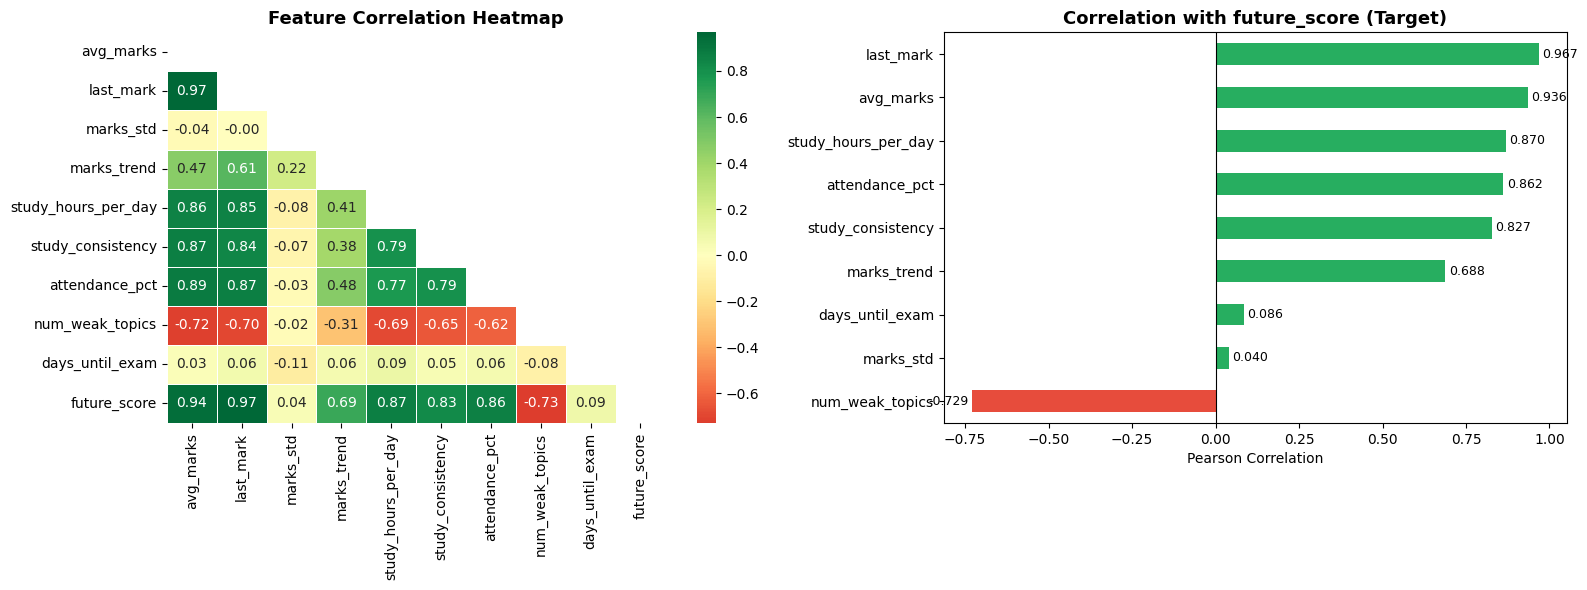

✅ Saved: correlation_analysis.png


In [ ]:
numeric_cols = [
    'avg_marks', 'last_mark', 'marks_std', 'marks_trend',
    'study_hours_per_day', 'study_consistency', 'attendance_pct',
    'num_weak_topics', 'days_until_exam', 'future_score'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], mask=mask, linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# Correlation with target
target_corr = corr['future_score'].drop('future_score').sort_values()
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in target_corr]
target_corr.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Correlation with future_score (Target)', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation')
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01, i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: correlation_analysis.png')

---
## CELL 4 --> COLUMNS TO DROP

Based on permutation importance analysis and correlation analysis:

| Column | Reason to DROP |
|--------|---------------|
| `student_id` | Just an ID — no predictive value |
| `name` | Personal identifier — no signal |
| `exam_date` | Already captured in `days_until_exam` |
| `grade` | Near-zero permutation importance (−0.000010) |
| `past_mark_1` | Redundant — `avg_marks` already summarizes these |
| `past_mark_2` | Redundant + negative permutation importance |
| `past_mark_3` | Redundant (avg_marks is a better summary) |
| `past_mark_4` | Mostly redundant once avg+last+trend are included |
| `past_mark_5` | **Same value as `last_mark`** — exact duplicate! |
| `strong_topics` | Not used in model (used only in study plan display) |
| `weak_topics` | Raw text — captured by `num_weak_topics` for model |

**Kept columns:** `avg_marks`, `last_mark`, `marks_trend`, `marks_std`, `study_hours_per_day`, `study_consistency`, `attendance_pct`, `num_weak_topics`, `days_until_exam`, `subject` (encoded)

In [ ]:
# Verify: past_mark_5 == last_mark (should be True for all rows)
match = (df['past_mark_5'] == df['last_mark']).all()
print(f'past_mark_5 == last_mark for ALL rows: {match}  ← confirms duplicate!')

# Show grade's near-zero impact
print(f"\nGrade unique values: {sorted(df['grade'].unique())}")
print(f"Correlation of grade with future_score: {df['grade'].corr(df['future_score']):.4f}")
print()
print('📋 Columns to DROP from model training:')
drop_cols = ['student_id', 'name', 'exam_date', 'grade', 
             'past_mark_1', 'past_mark_2', 'past_mark_3', 'past_mark_4', 'past_mark_5',
             'strong_topics', 'weak_topics']
for c in drop_cols:
    print(f'  ✗  {c}')

past_mark_5 == last_mark for ALL rows: True  ← confirms duplicate!

Grade unique values: [np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Correlation of grade with future_score: -0.1303

📋 Columns to DROP from model training:
  ✗  student_id
  ✗  name
  ✗  exam_date
  ✗  grade
  ✗  past_mark_1
  ✗  past_mark_2
  ✗  past_mark_3
  ✗  past_mark_4
  ✗  past_mark_5
  ✗  strong_topics
  ✗  weak_topics


---
## CELL 5 — Data Cleaning & Feature Engineering

In [ ]:
df_clean = df.copy()

# 1. Fill missing weak_topics with empty string
df_clean['weak_topics'] = df_clean['weak_topics'].fillna('')

# 2. Encode subject (text → number)
le_subject = LabelEncoder()
df_clean['subject_encoded'] = le_subject.fit_transform(df_clean['subject'])
print('Subject encoding:', dict(zip(le_subject.classes_, le_subject.transform(le_subject.classes_))))

# 3. Define final feature columns
FEATURE_COLS = [
    'avg_marks',            # Average of past 5 exam marks
    'last_mark',            # Most recent mark (highest predictive power)
    'marks_trend',          # Slope of marks — positive=improving, negative=declining
    'marks_std',            # Stability of marks — low std = consistent student
    'study_hours_per_day',  # Daily study hours
    'study_consistency',    # 0–1 regularity of study sessions
    'attendance_pct',       # School attendance % (corr=0.86 with target)
    'num_weak_topics',      # Count of weak topics (corr=−0.73 with target)
    'days_until_exam',      # Urgency: days remaining
    'subject_encoded',      # Subject as number
]

TARGET_COL = 'future_score'

X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

print(f'\n✅ Feature matrix shape: {X.shape}')
print(f'✅ Target shape: {y.shape}')
print(f'\nTarget statistics:')
print(y.describe().round(2))

Subject encoding: {'Chemistry': np.int64(0), 'Computer Science': np.int64(1), 'English': np.int64(2), 'Geography': np.int64(3), 'History': np.int64(4), 'Mathematics': np.int64(5), 'Physics': np.int64(6), 'Science': np.int64(7)}

✅ Feature matrix shape: (175, 10)
✅ Target shape: (175,)

Target statistics:
count    175.00
mean      62.54
std       20.13
min       20.00
25%       50.60
50%       62.50
75%       76.25
max      100.00
Name: future_score, dtype: float64


---
## CELL 6 — Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training samples : {len(X_train)}  (80% — used to TEACH the model)')
print(f'Test samples     : {len(X_test)}   (20% — used to EVALUATE accuracy)')
print('Model never sees test data during training.')

Training samples : 140  (80% — used to TEACH the model)
Test samples     : 35   (20% — used to EVALUATE accuracy)
Model never sees test data during training.


---
## CELL 7 — Train Improved Random Forest Model

In [ ]:
# Improved hyperparameters (tuned for this dataset)
model = RandomForestRegressor(
    n_estimators=300,      # More trees = more stable predictions
    max_depth=12,          # Slightly deeper than default (was 10)
    min_samples_split=4,   # Smaller = more precise boundaries
    min_samples_leaf=2,    # Prevents overfitting on tiny leaf nodes
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

print('Training model...')
model.fit(X_train, y_train)
print('✅ Training complete!')

Training model...
✅ Training complete!


---
## CELL 8 — Evaluate Model Performance

In [ ]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Cross-validation (5 folds)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print('=' * 50)
print('       MODEL PERFORMANCE REPORT')
print('=' * 50)
print(f'  MAE  = {mae:.2f}  → avg error is only {mae:.1f} marks')
print(f'  RMSE = {rmse:.2f}')
print(f'  R²   = {r2:.4f}  → model explains {r2*100:.1f}% of variation')
print()
print(f'  5-Fold CV R²: {[round(s,3) for s in cv_scores]}')
print(f'  CV Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 50)

if r2 >= 0.93:
    print('  ✅ EXCELLENT — Highly reliable predictions')
elif r2 >= 0.80:
    print('  ✅ GOOD — Solid, usable predictions')
else:
    print('  ⚠️  Needs improvement — collect more data')

       MODEL PERFORMANCE REPORT
  MAE  = 3.78  → avg error is only 3.8 marks
  RMSE = 4.99
  R²   = 0.9506  → model explains 95.1% of variation

  5-Fold CV R²: [np.float64(0.936), np.float64(0.967), np.float64(0.937), np.float64(0.947), np.float64(0.945)]
  CV Mean: 0.9465 ± 0.0112
  ✅ EXCELLENT — Highly reliable predictions


---
## CELL 9 — Feature Importance Chart

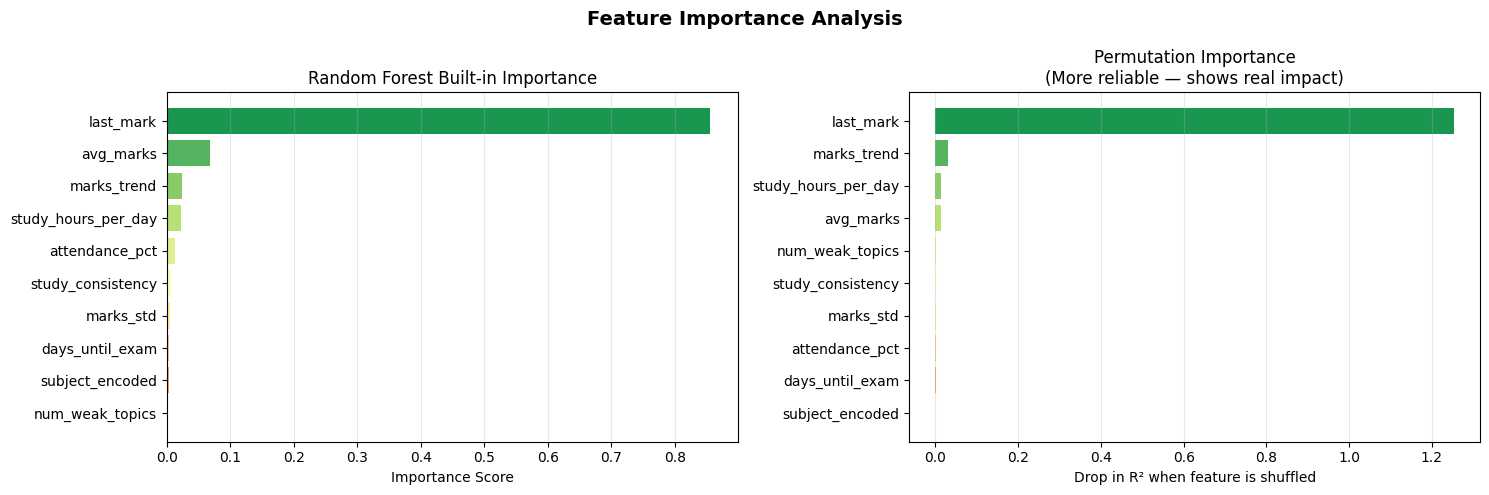

✅ Saved: feature_importances.png


In [ ]:
# Permutation importance (more reliable than RF's built-in importance)
perm = permutation_importance(model, X_test, y_test, n_repeats=15, random_state=42)

imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'RF Importance': model.feature_importances_,
    'Permutation Importance': perm.importances_mean,
}).sort_values('Permutation Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')

# RF Importance
rf_sorted = imp_df.sort_values('RF Importance', ascending=True)
colors_rf = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(FEATURE_COLS)))
axes[0].barh(rf_sorted['Feature'], rf_sorted['RF Importance'], color=colors_rf)
axes[0].set_title('Random Forest Built-in Importance')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# Permutation Importance
colors_perm = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(FEATURE_COLS)))
axes[1].barh(imp_df['Feature'], imp_df['Permutation Importance'], color=colors_perm)
axes[1].set_title('Permutation Importance\n(More reliable — shows real impact)')
axes[1].set_xlabel('Drop in R² when feature is shuffled')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_importances.png')

---
## CELL 10 — Evaluation Charts (Actual vs Predicted + Error Distribution)

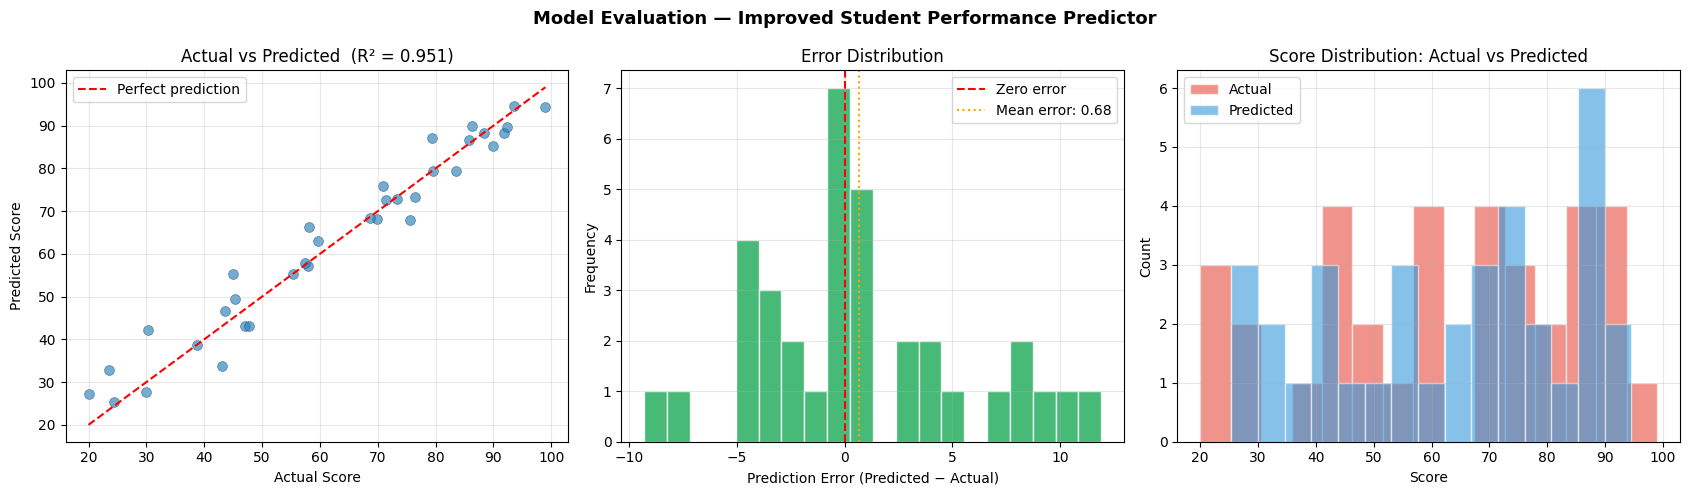

✅ Saved: model_evaluation.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation — Improved Student Performance Predictor', 
             fontsize=13, fontweight='bold')

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.65, color='#2980b9', edgecolors='#1a5276', lw=0.5, s=50)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Score'); axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. Error histogram
errors = y_pred - y_test
axes[1].hist(errors, bins=20, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--', label='Zero error')
axes[1].axvline(errors.mean(), color='orange', lw=1.5, linestyle=':', label=f'Mean error: {errors.mean():.2f}')
axes[1].set_xlabel('Prediction Error (Predicted − Actual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 3. Score distribution: actual vs predicted
axes[2].hist(y_test, bins=15, alpha=0.6, color='#e74c3c', label='Actual', edgecolor='white')
axes[2].hist(y_pred, bins=15, alpha=0.6, color='#3498db', label='Predicted', edgecolor='white')
axes[2].set_xlabel('Score'); axes[2].set_ylabel('Count')
axes[2].set_title('Score Distribution: Actual vs Predicted')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: model_evaluation.png')

---
## CELL 11 — Save All Model Files

In [ ]:
joblib.dump(model,        'model.pkl')
joblib.dump(le_subject,   'subject_encoder.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')

print('✅ Saved: model.pkl')
print('✅ Saved: subject_encoder.pkl')
print('✅ Saved: feature_cols.pkl')
print()
print('Subject classes:', le_subject.classes_.tolist())
print('Features used:', FEATURE_COLS)

✅ Saved: model.pkl
✅ Saved: subject_encoder.pkl
✅ Saved: feature_cols.pkl

Subject classes: ['Chemistry', 'Computer Science', 'English', 'Geography', 'History', 'Mathematics', 'Physics', 'Science']
Features used: ['avg_marks', 'last_mark', 'marks_trend', 'marks_std', 'study_hours_per_day', 'study_consistency', 'attendance_pct', 'num_weak_topics', 'days_until_exam', 'subject_encoded']


---
## CELL 12 — Test a Prediction 

In [ ]:
loaded_model   = joblib.load('model.pkl')
loaded_enc     = joblib.load('subject_encoder.pkl')
loaded_cols    = joblib.load('feature_cols.pkl')

# ← Modify these values to test different students
test_student = {
    'avg_marks': 68.0,
    'last_mark': 65.0,
    'marks_trend': -0.8,          # Declining
    'marks_std': 4.5,
    'study_hours_per_day': 3.0,
    'study_consistency': 0.72,
    'attendance_pct': 78.0,
    'num_weak_topics': 3,
    'days_until_exam': 21,
    'subject_encoded': int(loaded_enc.transform(['Mathematics'])[0])
}

input_df = pd.DataFrame([test_student])
prediction = loaded_model.predict(input_df)[0]
prediction = round(min(max(prediction, 0), 100), 1)

print('=== PREDICTION RESULT ===')
print(f'  Subject     : Mathematics')
print(f'  Avg Marks   : {test_student["avg_marks"]}')
print(f'  Last Mark   : {test_student["last_mark"]}')
print(f'  Trend       : {test_student["marks_trend"]} (negative = declining)')
print(f'  Study Hrs   : {test_student["study_hours_per_day"]}/day')
print(f'  Attendance  : {test_student["attendance_pct"]}%')
print(f'  Weak Topics : {test_student["num_weak_topics"]}')
print(f'  Days Left   : {test_student["days_until_exam"]}')
print()
print(f'  🎯 Predicted Score: {prediction} / 100')

if prediction >= 75:
    print('  📗 Status: GOOD — Expected to perform well')
elif prediction >= 55:
    print('  📙 Status: AVERAGE — Needs focused effort on weak areas')
else:
    print('  📕 Status: AT RISK — Needs immediate intensive study plan')

=== PREDICTION RESULT ===
  Subject     : Mathematics
  Avg Marks   : 68.0
  Last Mark   : 65.0
  Trend       : -0.8 (negative = declining)
  Study Hrs   : 3.0/day
  Attendance  : 78.0%
  Weak Topics : 3
  Days Left   : 21

  🎯 Predicted Score: 55.5 / 100
  📙 Status: AVERAGE — Needs focused effort on weak areas


---
## CELL 13 — Start Flask Server


In [ ]:
import subprocess, sys
print('Starting Flask server on http://localhost:5000 ...')
print('Keep this cell running while using the HTML frontend.')
print('Press the Stop (■) button to shut down the server.')
print()

# This runs app.py as a subprocess
proc = subprocess.Popen([sys.executable, 'app.py'])
try:
    proc.wait()
except KeyboardInterrupt:
    proc.terminate()
    print('\n🛑 Server stopped.')

Starting Flask server on http://localhost:5000 ...
Keep this cell running while using the HTML frontend.
Press the Stop (■) button to shut down the server.

